In [ ]:
# Importamos librerías necesarias.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Activation, Layer, Input
from tensorflow.keras.optimizers import RMSprop, Adam

import matplotlib.pyplot as plt
import math as mt
import numpy as np

In [ ]:
# Creamos la clase personalizada del modelo.
loss_tracker = keras.metrics.Mean(name="loss")

class red_funcion(keras.Model):
    def __init__(self, func, interval=[-1,1], batch_size=32, hidden=[64,64]):
        """
        func: Función que queremos aproximar.
        interval: Intervalo donde se va a entrenar.
        batch_size: Tamaño de lote.
        hidden: Lista con número de neuronas por capa oculta.
        """
        super(red_funcion, self).__init__()
        self.func = func
        self.a, self.b = interval
        self.batch_size = batch_size

        # Colocamos una arquitectura con 2 capas densas y una de salida.
        self.hidden_layers = [Dense(h, activation="tanh") for h in hidden]
        self.out_layer = Dense(1, activation=None)

    # Cambiamos el loss tracker.
    @property
    def metrics(self):
        return [loss_tracker]


    def call(self, x):
        z = x
        for layer in self.hidden_layers:
            z = layer(z)
        return self.out_layer(z)

    def train_step(self, data):
        # Muestreamos puntos aleatorios en el intervalo.
        x = tf.random.uniform((self.batch_size,1), minval=self.a, maxval=self.b)
        # Calculamos la salida real.
        y_true = self.func(x)

        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)
            # Colocamos MSE como la pérdida.
            loss = tf.reduce_mean(tf.square(y_true - y_pred))

        # Calculamos gradientes.
        grads = tape.gradient(loss, self.trainable_weights)
        # Actualizamos pesos.
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        # Actualiza la métrica de la función de pérdida.
        loss_tracker.update_state(loss)

        return {"loss": loss_tracker.result()}

In [ ]:
# Definimos las funciones que queremos aproximar.
f_a = lambda x: 3*tf.math.sin(mt.pi*x)
f_b = lambda x: 1 + 2*x + 4*tf.pow(x,3)

In [ ]:
# Aplicamos a capa a la función del inciso a.
model_a = red_funcion(f_a, interval=[-1,1], batch_size=32, hidden=[64,64])
# Escogemos parámetros de entrenamiento.
model_a.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01))

# Entrenamos al modelo.
history = model_a.fit(x=np.zeros((1000,1)), epochs=200, verbose=0)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


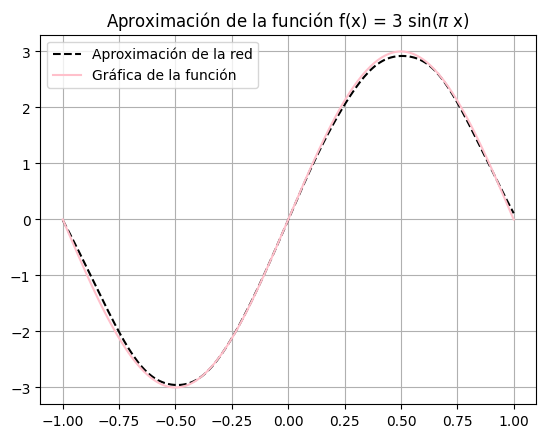

In [ ]:
# Graficamos el rendimiento de la red.
x = np.linspace(-1,1,200).reshape(-1,1)
# Predicciones de la red.
y_pred = model_a.predict(x)
plt.plot(x, y_pred, label="Aproximación de la red", linestyle="dashed", color='black')
plt.plot(x, f_a(x), label="Gráfica de la función", color='pink')
plt.legend()
plt.grid()
plt.title(r"Aproximación de la función f(x) = 3 sin($\pi$ x)")
plt.show()

In [ ]:
# Hacemos lo mismo con la función del inciso b.
# Colocamos un batch de 64, tres capas de 64 neuronas.
model_b = red_funcion(f_b, interval=[-1,1], batch_size=64, hidden=[64, 64, 64])
# Y optimizador Adam con el fin de mejorar la red y no haga una aproximación lineal.
model_b.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01))

history = model_b.fit(x=np.zeros((1000,1)), epochs=2000, verbose=0)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


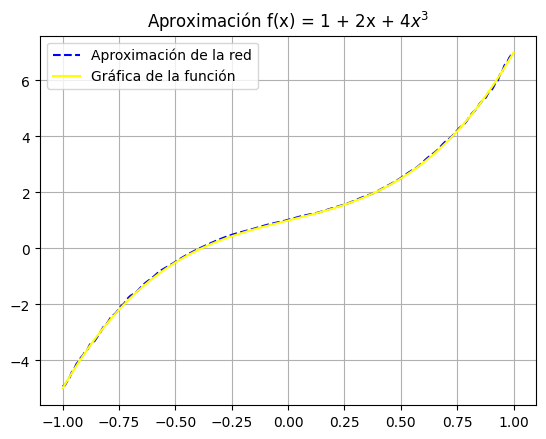

In [ ]:
# Predicción de la red.
y_pred2 = model_b.predict(x)
plt.plot(x, y_pred2, label="Aproximación de la red", linestyle="dashed", color='blue')
plt.plot(x, f_b(x), label="Gráfica de la función", color='yellow')
plt.legend()
plt.grid()
plt.title(r"Aproximación f(x) = 1 + 2x + 4$x^3$")
plt.show()